In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("football_player_rating_dataset (1).csv")

In [3]:
df.head()

,match_id,match_date,league_id,league_name,country_code,parent_league_name,parent_league_season,home_team_id,home_team_name,away_team_id,...,duels_won,duels_lost,ground_duels_won,ground_duel_attempts,ground_duel_success_rate,aerial_duels_won,aerial_duel_attempts,aerial_duel_success_rate,fouls_committed,was_fouled
0,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,4.0,NaN,4.0,4.0,100.000000,0.0,0.0,NaN,0,1.0
1,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,3.0,2.0,3.0,5.0,60.000000,0.0,0.0,NaN,1,NaN
2,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,100.000000,0,NaN
3,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,4.0,5.0,3.0,7.0,42.900002,1.0,2.0,50.000000,1,1.0
4,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,4.0,3.0,3.0,4.0,75.000000,1.0,3.0,33.299999,0,NaN


In [4]:
df.shape

(173587, 63)

In [5]:
df.columns

Index(['match_id', 'match_date', 'league_id', 'league_name', 'country_code',
       'parent_league_name', 'parent_league_season', 'home_team_id',
       'home_team_name', 'away_team_id', 'away_team_name', 'home_score',
       'away_score', 'is_home_team', 'team_goals', 'opponent_goals',
       'goal_difference', 'team_result', 'player_id', 'player_name', 'team_id',
       'team_name', 'is_goalkeeper', 'player_rating', 'minutes_played',
       'goals', 'assists', 'shots_on_target', 'blocked_shots',
       'expected_assists', 'xg_plus_xa', 'chances_created', 'touches',
       'touches_opp_box', 'successful_dribbles', 'dribble_attempts',
       'dribble_success_rate', 'accurate_passes', 'total_passes',
       'pass_accuracy', 'passes_final_third', 'accurate_crosses',
       'cross_attempts', 'cross_success_rate', 'accurate_long_balls',
       'long_ball_attempts', 'long_ball_success_rate', 'tackles_won',
       'interceptions', 'clearances', 'defensive_actions', 'recoveries',
       'drib

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173587 entries, 0 to 173586
Data columns (total 63 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   match_id                  173587 non-null  int64  
 1   match_date                173587 non-null  str    
 2   league_id                 173587 non-null  int64  
 3   league_name               173587 non-null  str    
 4   country_code              173587 non-null  str    
 5   parent_league_name        173587 non-null  str    
 6   parent_league_season      173587 non-null  int64  
 7   home_team_id              173587 non-null  int64  
 8   home_team_name            173587 non-null  str    
 9   away_team_id              173587 non-null  int64  
 10  away_team_name            173587 non-null  str    
 11  home_score                173587 non-null  int64  
 12  away_score                173587 non-null  int64  
 13  is_home_team              173587 non-null  int64  
 14 

In [7]:
df.isnull().sum()

match_id                        0
match_date                      0
league_id                       0
league_name                     0
country_code                    0
                            ...  
aerial_duels_won             4161
aerial_duel_attempts         4161
aerial_duel_success_rate    55560
fouls_committed                 0
was_fouled                  91436
Length: 63, dtype: int64

In [8]:
missing = df.isnull().sum()
missing[missing > 0]

team_goals                     253
opponent_goals                 253
goal_difference                253
minutes_played                1913
goals                        13128
assists                       5430
shots_on_target              92611
blocked_shots                13131
expected_assists            109655
xg_plus_xa                  103067
chances_created              12624
touches_opp_box              13142
successful_dribbles          90974
dribble_attempts             90974
dribble_success_rate         90974
pass_accuracy                 1206
passes_final_third           27046
accurate_crosses             98270
cross_attempts               98270
cross_success_rate           98270
accurate_long_balls          40887
long_ball_attempts           40887
long_ball_success_rate       40887
dribbled_past                13142
duels_won                    24579
duels_lost                   26509
ground_duels_won             19153
ground_duel_attempts         19153
ground_duel_success_

In [9]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

expected_assists      63.170053
xg_plus_xa            59.374838
accurate_crosses      56.611382
cross_success_rate    56.611382
cross_attempts        56.611382
                        ...    
defensive_actions      0.000000
tackles_won            0.000000
interceptions          0.000000
clearances             0.000000
fouls_committed        0.000000
Length: 63, dtype: float64

In [10]:
df["player_rating"].describe()

count    173587.000000
mean          6.777588
std           0.757662
min           2.430000
25%           6.230000
50%           6.690000
75%           7.280000
max           9.970000
Name: player_rating, dtype: float64

In [11]:
df["player_rating"].isnull().sum()

np.int64(0)

In [12]:
df["player_rating"].nunique()

650

In [13]:
df.describe(include="all")

,match_id,match_date,league_id,league_name,country_code,parent_league_name,parent_league_season,home_team_id,home_team_name,away_team_id,...,duels_won,duels_lost,ground_duels_won,ground_duel_attempts,ground_duel_success_rate,aerial_duels_won,aerial_duel_attempts,aerial_duel_success_rate,fouls_committed,was_fouled
count,1.735870e+05,173587,1.735870e+05,173587,173587,173587,173587.0,1.735870e+05,173587,1.735870e+05,...,149008.000000,147078.000000,154434.000000,154434.000000,154434.000000,169426.000000,169426.000000,118027.000000,173587.000000,82151.000000
unique,NaN,97,NaN,188,46,188,NaN,NaN,1231,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2025-04-05,NaN,Serie B,USA,Serie B,NaN,NaN,Barcelona,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5776,NaN,5903,18698,5903,NaN,NaN,527,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.083235e+06,NaN,7.463272e+05,NaN,NaN,NaN,2025.0,2.231961e+05,NaN,2.254658e+05,...,3.735786,3.839038,2.516868,5.069188,49.807614,0.991418,1.997102,48.616558,0.804352,1.611033
std,4.924875e+07,NaN,1.571397e+06,NaN,NaN,NaN,0.0,4.168852e+05,NaN,4.233537e+05,...,2.463674,2.512030,2.033597,3.326562,29.465689,1.461162,2.400656,38.608091,1.009219,0.929224
min,4.196553e+06,NaN,4.700000e+01,NaN,NaN,NaN,2025.0,1.567000e+03,NaN,1.567000e+03,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4.534715e+06,NaN,2.080000e+02,NaN,NaN,NaN,2025.0,8.239000e+03,NaN,8.239000e+03,...,2.000000,2.000000,1.000000,2.000000,33.299999,0.000000,0.000000,0.000000,0.000000,1.000000
50%,4.692715e+06,NaN,8.930330e+05,NaN,NaN,NaN,2025.0,9.863000e+03,NaN,9.860000e+03,...,3.000000,3.000000,2.000000,4.000000,50.000000,0.000000,1.000000,50.000000,1.000000,1.000000
75%,4.727522e+06,NaN,8.970320e+05,NaN,NaN,NaN,2025.0,1.930250e+05,NaN,1.917160e+05,...,5.000000,5.000000,4.000000,7.000000,66.699997,1.000000,3.000000,100.000000,1.000000,2.000000


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
[c for c in df.columns if "id" in c.lower()]

['match_id',
 'league_id',
 'home_team_id',
 'away_team_id',
 'player_id',
 'team_id']

In [16]:
df.duplicated(subset=["match_id", "player_id"]).sum()

np.int64(0)

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
match_id,173587.0,7.083235e+06,4.924875e+07,4196553.00,4.534715e+06,4692715.00,4.727522e+06,1.000001e+09
league_id,173587.0,7.463272e+05,1.571397e+06,47.00,2.080000e+02,893033.00,8.970320e+05,1.000000e+07
parent_league_season,173587.0,2.025000e+03,0.000000e+00,2025.00,2.025000e+03,2025.00,2.025000e+03,2.025000e+03
home_team_id,173587.0,2.231961e+05,4.168852e+05,1567.00,8.239000e+03,9863.00,1.930250e+05,1.730349e+06
away_team_id,173587.0,2.254658e+05,4.233537e+05,1567.00,8.239000e+03,9860.00,1.917160e+05,1.730349e+06
home_score,173587.0,1.554391e+00,1.336574e+00,0.00,1.000000e+00,1.00,2.000000e+00,9.000000e+00
away_score,173587.0,1.241988e+00,1.199033e+00,0.00,0.000000e+00,1.00,2.000000e+00,1.000000e+01
is_home_team,173587.0,4.947951e-01,4.999743e-01,0.00,0.000000e+00,0.00,1.000000e+00,1.000000e+00
team_goals,173334.0,1.379752e+00,1.274929e+00,0.00,0.000000e+00,1.00,2.000000e+00,1.000000e+01
opponent_goals,173334.0,1.414921e+00,1.282468e+00,0.00,0.000000e+00,1.00,2.000000e+00,1.000000e+01


In [18]:
df.describe().T[df.describe().T["min"] < 0]

,count,mean,std,min,25%,50%,75%,max
goal_difference,173334.0,-0.035169,1.819076,-9.0,-1.0,0.0,1.0,9.0


In [19]:
df.describe().T[df.describe().T["min"] < 0][["min", "25%", "50%", "75%", "max"]]

,min,25%,50%,75%,max
goal_difference,-9.0,-1.0,0.0,1.0,9.0


In [20]:
df["goal_difference"].value_counts().sort_index()

goal_difference
-9.0       43
-8.0       27
-7.0      167
-6.0      451
-5.0     1178
-4.0     3363
-3.0     8152
-2.0    18259
-1.0    35100
 0.0    42957
 1.0    33882
 2.0    17207
 3.0     7530
 4.0     3202
 5.0     1141
 6.0      441
 7.0      161
 8.0       31
 9.0       42
Name: count, dtype: int64

In [21]:
df["goals"].describe()

count    160459.000000
mean          0.092690
std           0.321375
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: goals, dtype: float64

In [22]:
df["assists"].describe()

count    168157.000000
mean          0.061336
std           0.253914
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: assists, dtype: float64

In [23]:
[c for c in df.columns if "minute" in c.lower()]

['minutes_played']

In [24]:
df["minutes_played"].describe()

count    171674.000000
mean         67.790091
std          27.571594
min          10.000000
25%          45.000000
50%          83.000000
75%          90.000000
max         120.000000
Name: minutes_played, dtype: float64

In [25]:
[c for c in df.columns if "shot" in c.lower()]

['shots_on_target', 'blocked_shots']

In [26]:
df["shots_on_target"].describe()

count    80976.000000
mean         0.592361
std          0.768307
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         13.000000
Name: shots_on_target, dtype: float64

In [27]:
df["blocked_shots"].describe()

count    160456.000000
mean          0.420894
std           0.667295
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           7.000000
Name: blocked_shots, dtype: float64

In [28]:
df["player_rating"].describe()

count    173587.000000
mean          6.777588
std           0.757662
min           2.430000
25%           6.230000
50%           6.690000
75%           7.280000
max           9.970000
Name: player_rating, dtype: float64

In [29]:
Q1 = df["player_rating"].quantile(0.25)
Q3 = df["player_rating"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Q1 = 6.230000019073486
Q3 = 7.28000020980835
IQR = 1.0500001907348633
Lower Bound = 4.654999732971191
Upper Bound = 8.855000495910645


In [30]:
outliers_rating = df[
    (df["player_rating"] < lower_bound) |
    (df["player_rating"] > upper_bound)
]

print("Number of outliers:", len(outliers_rating))
print("Percentage of outliers:", len(outliers_rating) / len(df) * 100)

Number of outliers: 2015
Percentage of outliers: 1.1608012120723326


In [31]:
outliers_rating[["player_name", "player_rating", "goals", "assists", "minutes_played"]].sort_values(
    "player_rating", ascending=False
).head(20)


,player_name,player_rating,goals,assists,minutes_played
170589,Bilal Sayoud,9.97,6.0,1.0,NaN
143465,Kevin Weggen,9.97,8.0,0.0,NaN
83346,Emre Yesilova,9.96,6.0,0.0,NaN
128364,Nils da Costa Perreira,9.96,5.0,0.0,NaN
158841,Marco Terrazzino,9.95,5.0,0.0,NaN
89275,Léa Le Garrec,9.92,1.0,3.0,90.0
37552,Kerem Senguen,9.91,3.0,3.0,NaN
75778,Brian White,9.91,4.0,0.0,90.0
170674,Domingos Pires,9.91,4.0,0.0,NaN
163889,Wessam Abou Ali,9.91,4.0,1.0,90.0


In [32]:
outliers_rating[["player_name", "player_rating", "goals", "assists", "minutes_played"]].sort_values(
    "player_rating", ascending=True
).head(20)

,player_name,player_rating,goals,assists,minutes_played
78361,Mathieu Gorgelin,2.43,NaN,0.0,90.0
142886,Paulo Vitor,2.49,NaN,0.0,47.0
66581,Bleron Berisha,2.51,NaN,0.0,NaN
116710,Kewin Komar,2.58,NaN,0.0,90.0
166689,Nicholas Hagen,2.79,NaN,0.0,90.0
128445,Anthony Cook,2.80,0.0,0.0,NaN
171355,Vance Wheaton,2.83,NaN,0.0,90.0
127835,Alex Bamford,2.90,0.0,0.0,90.0
162623,Casey Murphy,2.97,NaN,0.0,90.0
170574,Lonit Talla,3.06,0.0,0.0,NaN


In [33]:
mean_rating = df["player_rating"].mean()
std_rating = df["player_rating"].std()

lower_z = mean_rating - 3 * std_rating
upper_z = mean_rating + 3 * std_rating

print("Mean =", mean_rating)
print("Standard Deviation =", std_rating)
print("Lower Z-Score Bound =", lower_z)
print("Upper Z-Score Bound =", upper_z)

Mean = 6.777587665187197
Standard Deviation = 0.7576623691825431
Lower Z-Score Bound = 4.504600557639568
Upper Z-Score Bound = 9.050574772734826


In [34]:
outliers_z = df[
    (df["player_rating"] < lower_z) |
    (df["player_rating"] > upper_z)
]

print("Number of Z-Score outliers:", len(outliers_z))
print("Percentage of Z-Score outliers:", len(outliers_z) / len(df) * 100)

Number of Z-Score outliers: 1143
Percentage of Z-Score outliers: 0.6584594468479783



## 6. Outlier Detection & Treatment

Outliers were investigated using multiple methods, including the IQR method and the Z-Score method.

For the target variable `player_rating`, the IQR method identified 2,015 observations (1.16%) as potential outliers, while the Z-Score method identified 1,143 observations (0.66%).

After reviewing the extreme observations, the outliers were retained because extreme player ratings may represent genuine exceptional or poor performances rather than data-entry errors. 

In [35]:
df["goals"].value_counts().sort_index()

goals
0.0    146925
1.0     12348
2.0      1062
3.0       105
4.0        14
5.0         2
6.0         2
8.0         1
Name: count, dtype: int64

In [36]:
Q1_goals = df["goals"].quantile(0.25)
Q3_goals = df["goals"].quantile(0.75)

IQR_goals = Q3_goals - Q1_goals

lower_goals = Q1_goals - 1.5 * IQR_goals
upper_goals = Q3_goals + 1.5 * IQR_goals

print("Q1 =", Q1_goals)
print("Q3 =", Q3_goals)
print("IQR =", IQR_goals)
print("Lower Bound =", lower_goals)
print("Upper Bound =", upper_goals)

Q1 = 0.0
Q3 = 0.0
IQR = 0.0
Lower Bound = 0.0
Upper Bound = 0.0


In [37]:
print("Goals >= 3:", (df["goals"] >= 3).sum())
print("Goals >= 4:", (df["goals"] >= 4).sum())
print("Goals >= 5:", (df["goals"] >= 5).sum())

Goals >= 3: 124
Goals >= 4: 19
Goals >= 5: 5


In [38]:
df[df["goals"] >= 3][
    ["player_name", "goals", "minutes_played", "player_rating"]
].sort_values("goals", ascending=False)

,player_name,goals,minutes_played,player_rating
143465,Kevin Weggen,8.0,NaN,9.97
83346,Emre Yesilova,6.0,NaN,9.96
170589,Bilal Sayoud,6.0,NaN,9.97
158841,Marco Terrazzino,5.0,NaN,9.95
128364,Nils da Costa Perreira,5.0,NaN,9.96
...,...,...,...,...
170615,Francis Gerald Mampolo,3.0,NaN,8.87
170620,Kazaiah Sterling,3.0,NaN,9.85
170975,Ali Iyad Olwan,3.0,81.0,9.65
171455,Oscar Santis,3.0,71.0,9.75


In [39]:
df["assists"].value_counts().sort_index()

assists
0.0    158392
1.0      9247
2.0       487
3.0        31
Name: count, dtype: int64

In [40]:
df[df["assists"] == 3][
    ["player_name", "assists", "minutes_played", "player_rating"]
].sort_values("player_rating", ascending=False)

,player_name,assists,minutes_played,player_rating
89275,Léa Le Garrec,3.0,90.0,9.92
37552,Kerem Senguen,3.0,NaN,9.91
83225,Dominic Vose,3.0,NaN,9.88
158802,Sakariya Hassan,3.0,NaN,9.86
158869,Leon Maier,3.0,NaN,9.77
91196,Yousri Bouzok,3.0,88.0,9.73
88207,Riyad Mahrez,3.0,90.0,9.72
66810,Florian Kastrati,3.0,NaN,9.72
143383,Kazaiah Sterling,3.0,NaN,9.70
143451,Marco Cirillo,3.0,NaN,9.68


In [41]:
df["minutes_played"].isnull().sum()

np.int64(1913)

In [42]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

expected_assists            109655
xg_plus_xa                  103067
cross_success_rate           98270
cross_attempts               98270
accurate_crosses             98270
shots_on_target              92611
was_fouled                   91436
dribble_attempts             90974
successful_dribbles          90974
dribble_success_rate         90974
aerial_duel_success_rate     55560
accurate_long_balls          40887
long_ball_success_rate       40887
long_ball_attempts           40887
passes_final_third           27046
duels_lost                   26509
duels_won                    24579
ground_duel_success_rate     19153
ground_duel_attempts         19153
ground_duels_won             19153
touches_opp_box              13142
dribbled_past                13142
blocked_shots                13131
goals                        13128
chances_created              12624
assists                       5430
aerial_duel_attempts          4161
aerial_duels_won              4161
minutes_played      

In [43]:
df["expected_assists"].describe()

count    63932.000000
mean         0.084727
std          0.128121
min          0.010000
25%          0.010000
50%          0.030000
75%          0.100000
max          1.680000
Name: expected_assists, dtype: float64

In [44]:
df.groupby(df["expected_assists"].isnull())["minutes_played"].mean()

expected_assists
False    71.663095
True     65.491925
Name: minutes_played, dtype: float64

In [45]:
df[["expected_assists", "xg_plus_xa", "cross_attempts",
    "accurate_crosses", "shots_on_target"]].isnull().sum()

expected_assists    109655
xg_plus_xa          103067
cross_attempts       98270
accurate_crosses     98270
shots_on_target      92611
dtype: int64

In [46]:
missing_cols = [
    "expected_assists",
    "xg_plus_xa",
    "cross_attempts",
    "accurate_crosses",
    "shots_on_target"
]

missing_summary = pd.DataFrame({
    "Missing": df[missing_cols].isnull().sum(),
    "Present": df[missing_cols].notnull().sum(),
    "Missing_Percent": df[missing_cols].isnull().mean() * 100
})

missing_summary

,Missing,Present,Missing_Percent
expected_assists,109655,63932,63.170053
xg_plus_xa,103067,70520,59.374838
cross_attempts,98270,75317,56.611382
accurate_crosses,98270,75317,56.611382
shots_on_target,92611,80976,53.351345


In [47]:
df.groupby(df["shots_on_target"].isnull())["goals"].mean()

shots_on_target
False    0.183835
True     0.000000
Name: goals, dtype: float64

The missingness of shots_on_target is associated with zero goals in this dataset. However, missing values were not automatically replaced with zero without further investigation, because missingness may represent unavailable or unrecorded statistics rather than a true zero value

In [48]:
df.groupby(df["cross_attempts"].isnull())["goals"].mean()

cross_attempts
False    0.094826
True     0.090801
Name: goals, dtype: float64

cross_attempts has a high missing rate (56.61%). The mean number of goals is very similar between records with available and missing values (0.0948 vs. 0.0908). Therefore, no strong relationship between missingness in cross_attempts and goals was observed 

In [49]:
df.groupby(df["expected_assists"].isnull())["minutes_played"].mean()

expected_assists
False    71.663095
True     65.491925
Name: minutes_played, dtype: float64

expected_assists has 63.17% missing values. Records with missing values have a slightly lower average playing time (65.49 minutes) compared with records where the value is available (71.66 minutes). Due to the high missing rate, simple imputation was not applied at this stage.

In [50]:
df.groupby(df["xg_plus_xa"].isnull())["goals"].mean()

xg_plus_xa
False    0.104889
True     0.083331
Name: goals, dtype: float64

In [51]:
df.groupby(df["accurate_crosses"].isnull())["goals"].mean()

accurate_crosses
False    0.094826
True     0.090801
Name: goals, dtype: float64

ستون	Missing %	نتیجه فعلی
expected_assists	63.17%	Missing بسیار زیاد؛ فعلاً Imputation نکنیم
xg_plus_xa	59.37%	Missing بسیار زیاد؛ فعلاً Imputation نکنیم
cross_attempts	56.61%	اختلاف با goals ناچیز
accurate_crosses	56.61%	اختلاف با goals ناچیز
shots_on_target	53.35%	Missingها در این بررسی با 0 گل همراه بودند؛ نیاز به بررسی بیشتر

In [52]:
df.groupby(df["shots_on_target"].isnull())["player_rating"].mean()

shots_on_target
False    6.952408
True     6.624730
Name: player_rating, dtype: float64

Records with available shots_on_target have an average player_rating of 6.95, while records with missing values have an average rating of 6.62. This indicates a noticeable difference in player ratings between the two groups. Therefore, the missingness pattern should be considered during data preprocessing rather than automatically replacing missing values with zero

In [53]:
df.groupby(df["expected_assists"].isnull())["player_rating"].mean()

expected_assists
False    6.894102
True     6.709656
Name: player_rating, dtype: float64

In [54]:
df.groupby(df["xg_plus_xa"].isnull())["player_rating"].mean()

xg_plus_xa
False    6.866365
True     6.716845
Name: player_rating, dtype: float64

In [55]:
df.groupby(df["cross_attempts"].isnull())["player_rating"].mean()

cross_attempts
False    6.876422
True     6.701838
Name: player_rating, dtype: float64

In [56]:
df.groupby(df["accurate_crosses"].isnull())["player_rating"].mean()

accurate_crosses
False    6.876422
True     6.701838
Name: player_rating, dtype: float64

In [57]:
missing_summary_all = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Missing_Percent": df.isnull().mean() * 100
})

missing_summary_all = missing_summary_all[
    missing_summary_all["Missing"] > 0
].sort_values("Missing_Percent", ascending=False)

missing_summary_all

,Missing,Missing_Percent
expected_assists,109655,63.170053
xg_plus_xa,103067,59.374838
cross_success_rate,98270,56.611382
cross_attempts,98270,56.611382
accurate_crosses,98270,56.611382
shots_on_target,92611,53.351345
was_fouled,91436,52.674451
dribble_attempts,90974,52.408302
successful_dribbles,90974,52.408302
dribble_success_rate,90974,52.408302


In [58]:
missing_summary_all[missing_summary_all["Missing_Percent"] > 30]

,Missing,Missing_Percent
expected_assists,109655,63.170053
xg_plus_xa,103067,59.374838
cross_success_rate,98270,56.611382
cross_attempts,98270,56.611382
accurate_crosses,98270,56.611382
shots_on_target,92611,53.351345
was_fouled,91436,52.674451
dribble_attempts,90974,52.408302
successful_dribbles,90974,52.408302
dribble_success_rate,90974,52.408302


### Missing Values Summary

The dataset contains missing values in several performance-related features. 
Eleven variables have more than 30% missing values, with `expected_assists` 
having the highest missing rate (63.17%).

Several variables show identical missing counts, such as `cross_attempts`, 
`accurate_crosses`, and `cross_success_rate`, as well as `dribble_attempts`, 
`successful_dribbles`, and `dribble_success_rate`. This pattern suggests 
that missingness may be related to the availability of certain statistics 
rather than being completely random.

Therefore, missing values were not automatically replaced with zero, mean, 
or median values. The final treatment will be determined during the 
data-preprocessing and machine-learning stage.

In [59]:
df["was_fouled"].value_counts(dropna=False)

was_fouled
NaN     91436
1.0     49426
2.0     20967
3.0      7826
4.0      2686
5.0       859
6.0       276
7.0        85
8.0        15
9.0        10
10.0        1
Name: count, dtype: int64

In [60]:
df.groupby(df["was_fouled"].isnull())["player_rating"].mean()

was_fouled
False    6.909792
True     6.658808
Name: player_rating, dtype: float64

In [61]:
df.groupby(df["dribble_attempts"].isnull())["player_rating"].mean()

dribble_attempts
False    6.896485
True     6.669617
Name: player_rating, dtype: float64

In [62]:
df.groupby(df["successful_dribbles"].isnull())["player_rating"].mean()

successful_dribbles
False    6.896485
True     6.669617
Name: player_rating, dtype: float64

In [63]:
df.groupby(df["dribble_success_rate"].isnull())["player_rating"].mean()

dribble_success_rate
False    6.896485
True     6.669617
Name: player_rating, dtype: float64

In [64]:
df.groupby(df["aerial_duel_success_rate"].isnull())["player_rating"].mean()

aerial_duel_success_rate
False    6.825857
True     6.675049
Name: player_rating, dtype: float64

## 7. Missing Values Analysis and Decision

Missing values were investigated by calculating both the number and percentage of missing observations. Eleven variables contained more than 30% missing values.

The highest missing rate was observed in `expected_assists` (63.17%), followed by `xg_plus_xa` (59.37%). Several crossing and dribbling variables also had high and identical missing rates.

The relationship between missingness and `player_rating` was also investigated. For all examined variables, records with missing values showed a lower average player rating than records with available values.

However, missing values were not automatically replaced with zero, mean, or median values. Due to the high proportion of missing observations and the observed missingness patterns, deleting all rows with missing values could result in substantial information loss.

Therefore, missing values will be handled during the data preprocessing stage according to the requirements of the selected machine-learning model. Any imputation will be fitted using the training data only to avoid data leakage.

In [65]:
numeric_cols = df.select_dtypes(include=np.number).columns

negative_values = df[numeric_cols].lt(0).sum()
negative_values[negative_values > 0]

goal_difference    66740
dtype: int64

In [66]:
df.loc[df["goal_difference"] < 0, "goal_difference"].value_counts().sort_index()

goal_difference
-9.0       43
-8.0       27
-7.0      167
-6.0      451
-5.0     1178
-4.0     3363
-3.0     8152
-2.0    18259
-1.0    35100
Name: count, dtype: int64

### Negative Values Investigation

A check for negative values showed that only `goal_difference` contains negative observations.

The negative values range from -1 to -9 and represent matches in which the player's team scored fewer goals than the opponent.

Therefore, these values are considered valid football match outcomes and were not removed or modified.

In [67]:
df["goals"].value_counts().sort_index()

goals
0.0    146925
1.0     12348
2.0      1062
3.0       105
4.0        14
5.0         2
6.0         2
8.0         1
Name: count, dtype: int64

### Goals Validation

The `goals` variable contains only non-negative values ranging from 0 to 8.

Most observations correspond to players who scored 0 goals, while higher values are rare and represent exceptional scoring performances.

No negative or invalid values were detected, so no observations were removed or modified based on the `goals` variable.

In [68]:
df["assists"].value_counts().sort_index()

assists
0.0    158392
1.0      9247
2.0       487
3.0        31
Name: count, dtype: int64

In [69]:
df["assists"].describe()

count    168157.000000
mean          0.061336
std           0.253914
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: assists, dtype: float64

In [70]:
df["assists"].isnull().sum()

np.int64(5430)

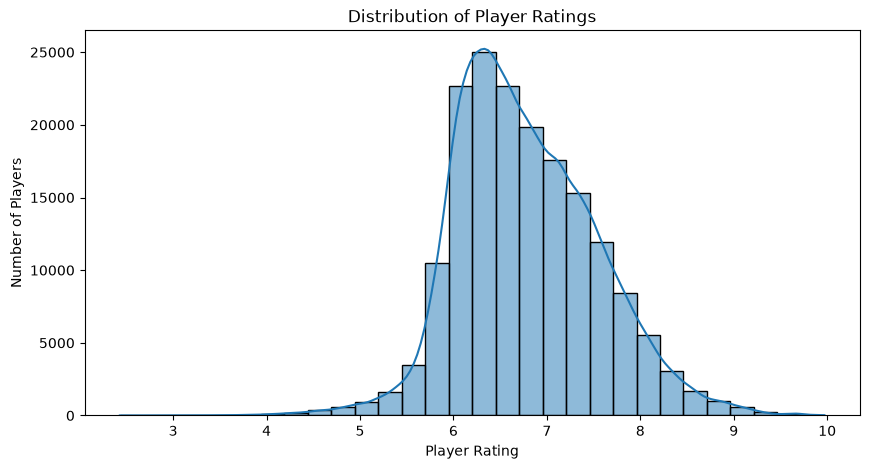

In [71]:
plt.figure(figsize=(10, 5))
sns.histplot(df["player_rating"], bins=30, kde=True)
plt.title("Distribution of Player Ratings")
plt.xlabel("Player Rating")
plt.ylabel("Number of Players")
plt.show()

In [72]:
[c for c in df.columns if "result" in c.lower() or "win" in c.lower()]

['team_result']

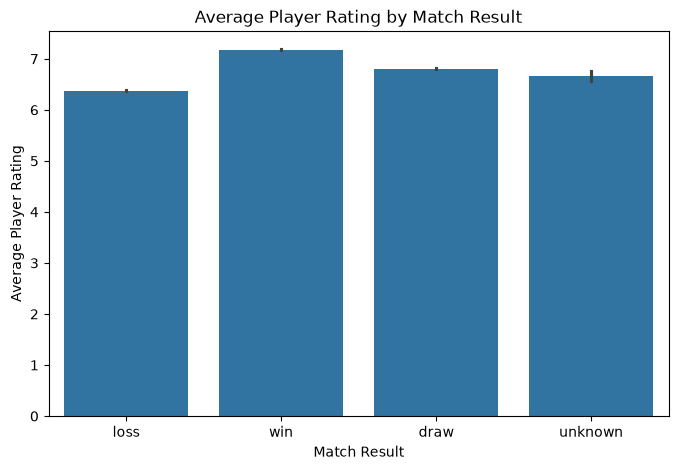

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=df["team_result"],
    y=df["player_rating"]
)

plt.title("Average Player Rating by Match Result")
plt.xlabel("Match Result")
plt.ylabel("Average Player Rating")
plt.show()

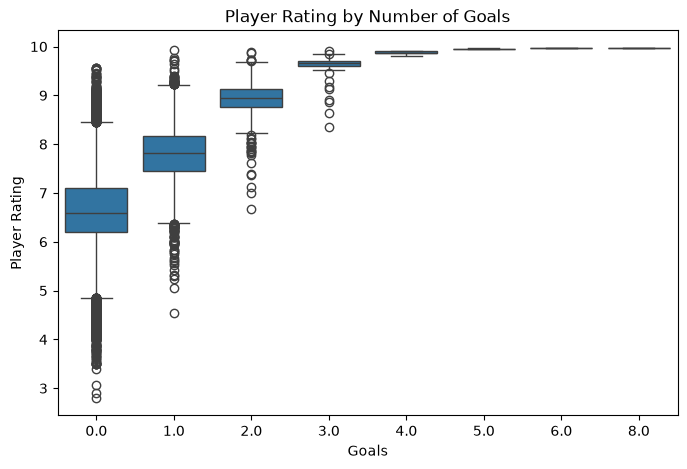

In [74]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["goals"],
    y=df["player_rating"]
)

plt.title("Player Rating by Number of Goals")
plt.xlabel("Goals")
plt.ylabel("Player Rating")
plt.show()

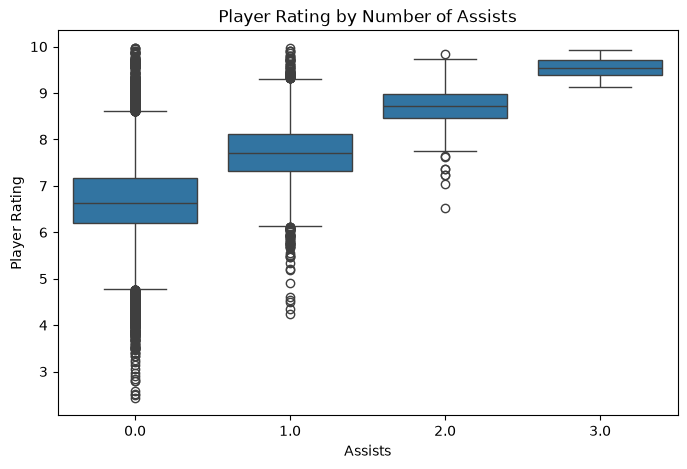

In [75]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["assists"],
    y=df["player_rating"]
)

plt.title("Player Rating by Number of Assists")
plt.xlabel("Assists")
plt.ylabel("Player Rating")
plt.show()

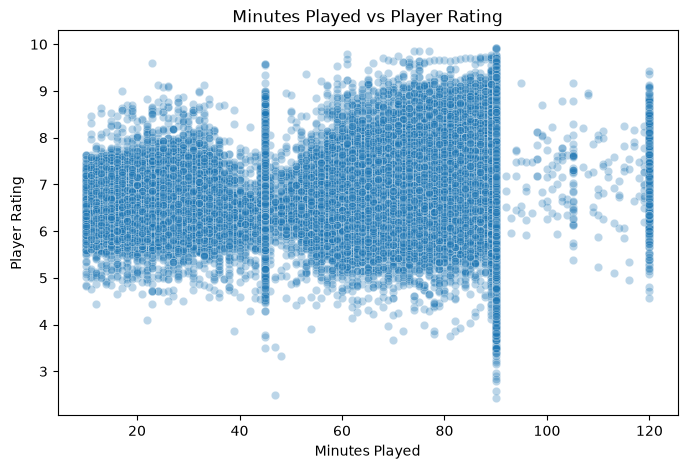

In [76]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["minutes_played"],
    y=df["player_rating"],
    alpha=0.3
)

plt.title("Minutes Played vs Player Rating")
plt.xlabel("Minutes Played")
plt.ylabel("Player Rating")
plt.show()

In [77]:
corr = df.select_dtypes(include=np.number).corr()["player_rating"].sort_values(ascending=False)

corr

player_rating               1.000000
goals                       0.493008
goal_difference             0.470892
ground_duels_won            0.413076
touches                     0.408710
shots_on_target             0.408466
chances_created             0.400336
xg_plus_xa                  0.394779
minutes_played              0.382578
duels_won                   0.382287
assists                     0.342226
total_passes                0.332181
recoveries                  0.328277
team_goals                  0.315246
successful_dribbles         0.315014
ground_duel_success_rate    0.303785
defensive_actions           0.302628
accurate_passes             0.302268
tackles_won                 0.295214
expected_assists            0.275030
touches_opp_box             0.274297
ground_duel_attempts        0.255301
dribble_success_rate        0.250160
passes_final_third          0.232437
accurate_crosses            0.227060
interceptions               0.217296
cross_attempts              0.193845
c

In [78]:
corr = df.select_dtypes(include=np.number).corr()["player_rating"]

corr.sort_values(ascending=False).head(11)

player_rating       1.000000
goals               0.493008
goal_difference     0.470892
ground_duels_won    0.413076
touches             0.408710
shots_on_target     0.408466
chances_created     0.400336
xg_plus_xa          0.394779
minutes_played      0.382578
duels_won           0.382287
assists             0.342226
Name: player_rating, dtype: float64

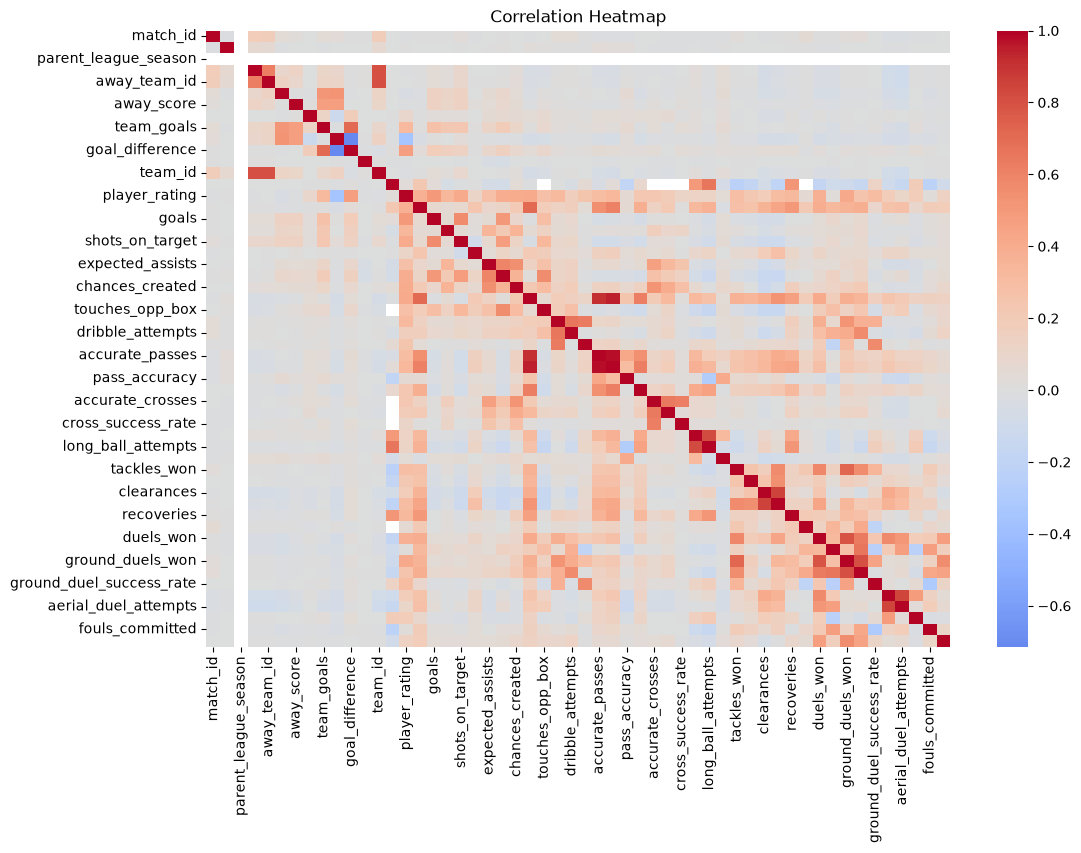

In [79]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [80]:
df.columns.tolist()

['match_id',
 'match_date',
 'league_id',
 'league_name',
 'country_code',
 'parent_league_name',
 'parent_league_season',
 'home_team_id',
 'home_team_name',
 'away_team_id',
 'away_team_name',
 'home_score',
 'away_score',
 'is_home_team',
 'team_goals',
 'opponent_goals',
 'goal_difference',
 'team_result',
 'player_id',
 'player_name',
 'team_id',
 'team_name',
 'is_goalkeeper',
 'player_rating',
 'minutes_played',
 'goals',
 'assists',
 'shots_on_target',
 'blocked_shots',
 'expected_assists',
 'xg_plus_xa',
 'chances_created',
 'touches',
 'touches_opp_box',
 'successful_dribbles',
 'dribble_attempts',
 'dribble_success_rate',
 'accurate_passes',
 'total_passes',
 'pass_accuracy',
 'passes_final_third',
 'accurate_crosses',
 'cross_attempts',
 'cross_success_rate',
 'accurate_long_balls',
 'long_ball_attempts',
 'long_ball_success_rate',
 'tackles_won',
 'interceptions',
 'clearances',
 'defensive_actions',
 'recoveries',
 'dribbled_past',
 'duels_won',
 'duels_lost',
 'ground_du

In [81]:
columns_to_drop = [
    "match_id",
    "league_id",
    "league_name",
    "country_code",
    "parent_league_name",
    "parent_league_season",
    "home_team_id",
    "home_team_name",
    "away_team_id",
    "away_team_name",
    "player_id",
    "player_name",
    "team_id",
    "team_name",
    "match_date"
]

columns_to_drop

['match_id',
 'league_id',
 'league_name',
 'country_code',
 'parent_league_name',
 'parent_league_season',
 'home_team_id',
 'home_team_name',
 'away_team_id',
 'away_team_name',
 'player_id',
 'player_name',
 'team_id',
 'team_name',
 'match_date']

In [82]:
df_model = df.drop(columns=columns_to_drop)

df_model.shape

(173587, 48)

In [83]:
df_model.select_dtypes(include="object").columns.tolist()

C:\Users\Milano\AppData\Local\Temp\ipykernel_16492\2940521981.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.select_dtypes(include="object").columns.tolist()


['team_result']

In [84]:
df_model["team_result"].value_counts()

team_result
loss       66740
win        63637
draw       42957
unknown      253
Name: count, dtype: int64

In [85]:
df_model[df_model["team_result"] == "unknown"].head()

,home_score,away_score,is_home_team,team_goals,opponent_goals,goal_difference,team_result,is_goalkeeper,player_rating,minutes_played,...,duels_won,duels_lost,ground_duels_won,ground_duel_attempts,ground_duel_success_rate,aerial_duels_won,aerial_duel_attempts,aerial_duel_success_rate,fouls_committed,was_fouled
4543,2,0,0,NaN,NaN,NaN,unknown,0,5.70,12.0,...,NaN,2.0,0.0,1.0,0.000000,0.0,1.0,0.000000,0,NaN
4544,2,0,0,NaN,NaN,NaN,unknown,0,6.20,79.0,...,1.0,4.0,1.0,4.0,25.000000,0.0,1.0,0.000000,2,1.0
4545,2,0,0,NaN,NaN,NaN,unknown,0,6.27,11.0,...,1.0,NaN,1.0,1.0,100.000000,0.0,0.0,NaN,0,NaN
4546,2,0,0,NaN,NaN,NaN,unknown,0,6.13,67.0,...,3.0,3.0,1.0,3.0,33.299999,2.0,3.0,66.699997,1,2.0
4547,2,0,0,NaN,NaN,NaN,unknown,0,6.05,35.0,...,2.0,7.0,0.0,5.0,0.000000,2.0,4.0,50.000000,2,NaN


In [86]:
df_model = df_model[df_model["team_result"] != "unknown"].copy()

df_model.shape

(173334, 48)

In [87]:
df_model["team_result"] = df_model["team_result"].map({
    "loss": 0,
    "draw": 1,
    "win": 2
})

df_model["team_result"].value_counts().sort_index()

team_result
0    66740
1    42957
2    63637
Name: count, dtype: int64

In [88]:
X = df_model.drop(columns=["player_rating"])
y = df_model["player_rating"]

X.shape, y.shape

((173334, 47), (173334,))

In [89]:
X.isnull().sum().sort_values(ascending=False).head(15)

expected_assists            109411
xg_plus_xa                  102824
accurate_crosses             98116
cross_success_rate           98116
cross_attempts               98116
shots_on_target              92476
was_fouled                   91306
dribble_attempts             90835
successful_dribbles          90835
dribble_success_rate         90835
aerial_duel_success_rate     55458
long_ball_attempts           40828
accurate_long_balls          40828
long_ball_success_rate       40828
passes_final_third           27006
dtype: int64

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((138667, 47), (34667, 47), (138667,), (34667,))

In [91]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
import sklearn
print(sklearn.__version__)

1.9.0


In [93]:
%pip --version

pip 26.1.1 from c:\Users\Milano\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip (python 3.14)

Note: you may need to restart the kernel to use updated packages.


In [94]:
import sys
print(sys.executable)

c:\Users\Milano\AppData\Local\Programs\Python\Python314\python.exe


In [95]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
%pip install scikit-learn --index-url https://pypi.org/simple

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import sklearn
print(sklearn.__version__)

1.9.0


In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
df = pd.read_csv("football_player_rating_dataset (1).csv")

print(df.shape)

(173587, 63)


In [101]:
columns_to_drop = [
    "match_id",
    "league_id",
    "league_name",
    "country_code",
    "parent_league_name",
    "parent_league_season",
    "home_team_id",
    "home_team_name",
    "away_team_id",
    "away_team_name",
    "player_id",
    "player_name",
    "team_id",
    "team_name",
    "match_date"
]

df_model = df.drop(columns=columns_to_drop)

print(df_model.shape)

(173587, 48)


In [102]:
df_model = df_model[df_model["team_result"] != "unknown"].copy()

print(df_model.shape)

(173334, 48)


In [103]:
df_model["team_result"] = df_model["team_result"].map({
    "loss": 0,
    "draw": 1,
    "win": 2
})

print(df_model["team_result"].value_counts().sort_index())

team_result
0    66740
1    42957
2    63637
Name: count, dtype: int64


In [104]:
X = df_model.drop(columns=["player_rating"])
y = df_model["player_rating"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (173334, 47)
y shape: (173334,)


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (138667, 47)
X_test: (34667, 47)
y_train: (138667,)
y_test: (34667,)


In [106]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("X_train:", X_train_imputed.shape)
print("X_test:", X_test_imputed.shape)

X_train: (138667, 47)
X_test: (34667, 47)


In [107]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imputed, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test_imputed)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.19240785024000384
RMSE: 0.29199869974477516
R²: 0.8515452669482577


In [109]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
9,goals,0.210088
16,touches,0.170262
41,ground_duel_success_rate,0.081975
5,goal_difference,0.075241
6,team_result,0.068524
10,assists,0.067562
4,opponent_goals,0.048031
15,chances_created,0.035511
35,recoveries,0.034358
34,defensive_actions,0.019179


Goals was the most important feature for predicting player rating, followed by touches and ground duel success rate .

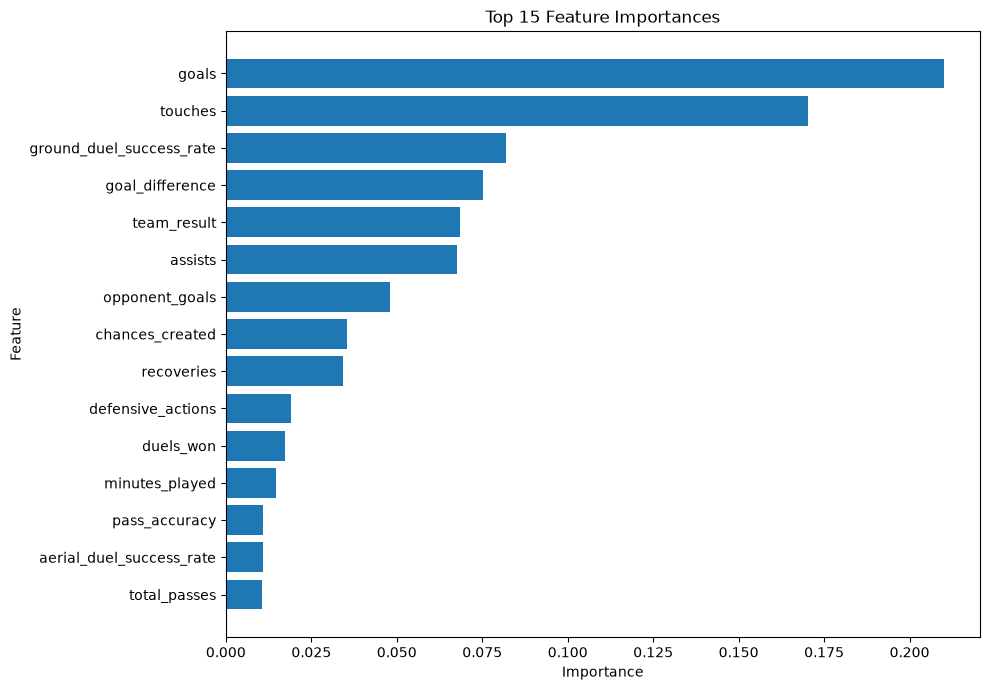

In [110]:
top_features = feature_importance.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 10. Conclusion

This project analyzed a real-world football player performance dataset containing 173,587 player-match records.

The EDA showed that player ratings are strongly related to performance indicators such as goals, goal difference, touches, ground duels, shots on target, chances created, and assists. Outliers were investigated using both IQR and Z-Score methods and were retained because they represented realistic extreme performances rather than obvious data errors.

Missing values were also investigated. Due to the high proportion and non-random pattern of missing values in several variables, rows were not removed. Instead, missing values were handled during the machine-learning preprocessing stage using median imputation fitted only on the training data.

A Random Forest Regression model was used to predict player ratings. The model achieved an MAE of 0.192, an RMSE of 0.292, and an R² of 0.852, indicating good predictive performance. The most important features included goals, touches, ground duel success rate, goal difference, team result, and assists.

Finally, a Power BI dashboard was created to provide interactive analysis of player performance across leagues, teams, match results, goals, assists, minutes played, and goalkeeper status.